In [1]:
import sys
from pathlib import Path

for candidate in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
    if (candidate / "src" / "cnn_model.py").is_file():
        if str(candidate) not in sys.path:
            sys.path.insert(0, str(candidate))
        break
else:
    raise FileNotFoundError("Could not find the project root (folder that contains src/)")

from src.preprocessing import get_dataloaders
from src.cnn_model import CNN

# loaders = get_dataloaders(batch_size=32, image_size=224)  # RGB
loaders = get_dataloaders(use_ela=True, batch_size=32, image_size=224)                # CNN + ELA

In [2]:
model = CNN(input_channel=3, output_channels=[128, 256, 512])
n_params = sum(p.numel() for p in model.parameters())
print(f"Number of parameters: {n_params}")


Number of parameters: 1481730


In [3]:
history = model.fit(loaders["train"], loaders["val"])

Epoch 1/10, Train Loss: 0.3446, Train Accuracy: 0.8622, Val Loss: 0.3539, Val Accuracy: 0.8771
Epoch 2/10, Train Loss: 0.2899, Train Accuracy: 0.8846, Val Loss: 0.3100, Val Accuracy: 0.8755
Epoch 3/10, Train Loss: 0.2521, Train Accuracy: 0.8984, Val Loss: 0.2203, Val Accuracy: 0.9040
Epoch 4/10, Train Loss: 0.2375, Train Accuracy: 0.8990, Val Loss: 0.2665, Val Accuracy: 0.9025
Epoch 5/10, Train Loss: 0.2307, Train Accuracy: 0.9028, Val Loss: 0.2103, Val Accuracy: 0.9096
Epoch 6/10, Train Loss: 0.2157, Train Accuracy: 0.9097, Val Loss: 0.2369, Val Accuracy: 0.8969
Epoch 7/10, Train Loss: 0.2110, Train Accuracy: 0.9104, Val Loss: 0.2278, Val Accuracy: 0.8906
Epoch 8/10, Train Loss: 0.2093, Train Accuracy: 0.9102, Val Loss: 0.2565, Val Accuracy: 0.8929
Epoch 9/10, Train Loss: 0.2119, Train Accuracy: 0.9104, Val Loss: 0.1908, Val Accuracy: 0.9144
Epoch 10/10, Train Loss: 0.1959, Train Accuracy: 0.9164, Val Loss: 0.2057, Val Accuracy: 0.9104


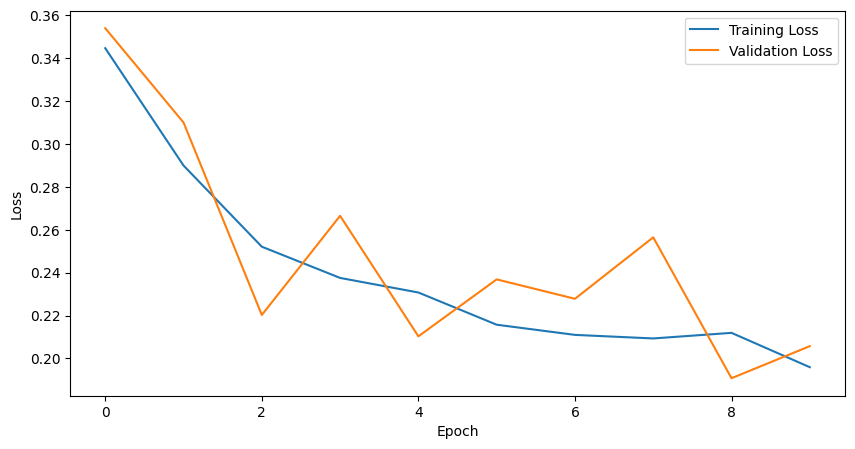

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(history[0]["train_loss"], label="Training Loss")
plt.plot(history[0]["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [7]:
preds = model.predict(next(iter(loaders["test"]))[0])
preds = preds.to('cpu')

In [8]:
# calculate the accuracy
accuracy = (preds == next(iter(loaders["test"]))[1]).sum().item() / len(next(iter(loaders["test"]))[1])
print(f"Accuracy: {accuracy}")

Accuracy: 0.84375
